In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")

In [29]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,Ontime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,Ontime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,Ontime,14.52,1,0,4.18,9.22


In [28]:
orders.head()
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,Sme,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,Airport,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,Central,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [27]:
datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

customers (650, 9)
orders (1250, 11)
deliveries (950, 13)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
complaints (320, 10)
incidents (280, 7)
app_events (640, 10)


In [26]:
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 customers
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

 orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

 deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing  

In [8]:
for name, df in datasets.items():
    print("\n", name)
    print(df.columns.tolist())


 customers
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

 orders
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

 deliveries
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

 drivers
['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

 vehicles
['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version']

 hubs
['hub_id', 'hub_name', 'zone', 'hub_type', '

In [9]:
for col in ["pickup_zone", "dropoff_zone", "service_type", "priority_level"]:
    if col in orders.columns:
        orders[col] = orders[col].astype(str).str.strip().str.title()

for col in ["delivery_status"]:
    if col in deliveries.columns:
        deliveries[col] = deliveries[col].astype(str).str.strip().str.title()

for col in ["home_zone", "customer_type"]:
    if col in customers.columns:
        customers[col] = customers[col].astype(str).str.strip().str.title()

for col in ["zone"]:
    if col in hubs.columns:
        hubs[col] = hubs[col].astype(str).str.strip().str.title()

In [10]:
main_df = deliveries.merge(orders, on="order_id", how="left")
main_df = main_df.merge(customers, on="customer_id", how="left")
main_df = main_df.merge(drivers, on="driver_id", how="left")
main_df = main_df.merge(vehicles, on="vehicle_id", how="left")
main_df = main_df.merge(hubs, on="hub_id", how="left")

main_df.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,CENTRAL,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,Ontime,10.34,1,...,AIRPORT,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,Ontime,7.92,0,...,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,Ontime,14.52,1,...,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


In [11]:
main_df.shape

(950, 49)

In [32]:
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count")
).reset_index()

In [13]:
main_df = main_df.merge(complaint_summary, on="order_id", how="left")
main_df = main_df.merge(incident_summary, on="delivery_id", how="left")

main_df["complaint_count"] = main_df["complaint_count"].fillna(0)
main_df["incident_count"] = main_df["incident_count"].fillna(0)
main_df["total_compensation"] = main_df["total_compensation"].fillna(0)

main_df.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score,complaint_count,avg_resolution_days,total_compensation,incident_count
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Active,v2.2,Central Core,Central,Control,88,0.0,NaN,0.0,1.0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,Ontime,10.34,1,...,Active,v2.2,South Link,South,Dispatch,78,0.0,NaN,0.0,0.0
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,Ontime,7.92,0,...,Active,v2.2,South Link,South,Dispatch,78,0.0,NaN,0.0,0.0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,Active,v2.1,South Link,South,Dispatch,78,0.0,NaN,0.0,0.0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,Ontime,14.52,1,...,InRepair,v2.0,North Exchange,North,Dispatch,82,0.0,NaN,0.0,0.0


In [14]:
main_df["is_failed"] = (main_df["delivery_status"] == "Failed").astype(int)
main_df["has_complaint"] = (main_df["complaint_count"] > 0).astype(int)
main_df["has_incident"] = (main_df["incident_count"] > 0).astype(int)

main_df["high_route_override"] = (main_df["manual_route_override_count"] >= 3).astype(int)

if "battery_health_pct" in main_df.columns:
    main_df["low_battery_health"] = (main_df["battery_health_pct"] < 70).astype(int)

In [33]:
failure_by_zone = main_df.groupby("zone")["is_failed"].mean().sort_values(ascending=False) * 100
failure_by_zone

,is_failed
zone,
Central,20.164609
Airport,14.423077
West,12.598425
North,12.500000
Riverside,12.173913
South,9.433962
East,9.243697


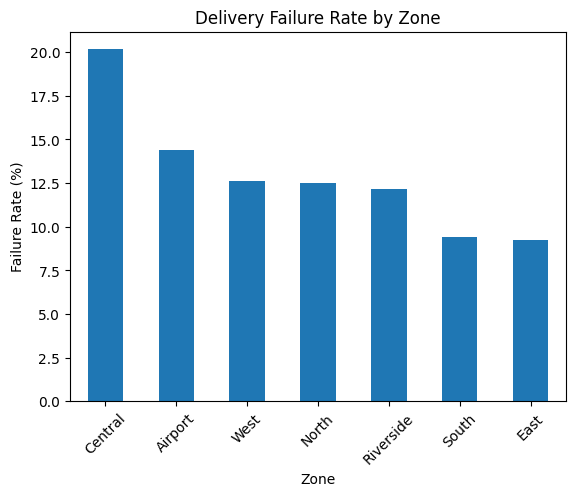

In [16]:
failure_by_zone.plot(kind="bar")
plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [34]:
rating_by_status = main_df.groupby("delivery_status")["customer_rating_post_delivery"].mean().sort_values()
rating_by_status

,customer_rating_post_delivery
delivery_status,
Failed,3.049313
Delayed,3.114975
Ontime,4.283273


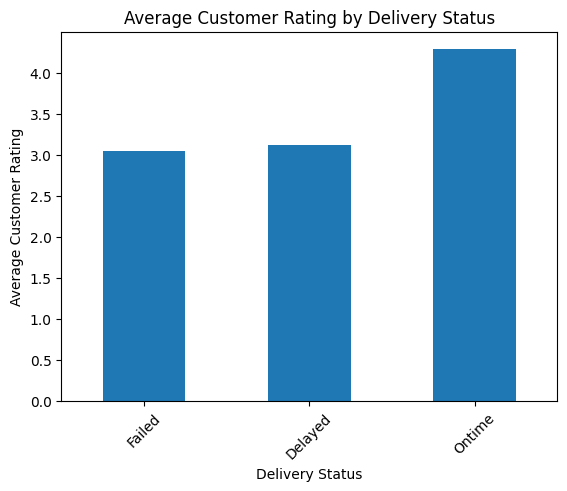

In [18]:
rating_by_status.plot(kind="bar")
plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Customer Rating")
plt.xticks(rotation=45)
plt.show()

In [19]:
override_cost = main_df.groupby("manual_route_override_count")["fuel_or_charge_cost"].mean()
override_cost

,fuel_or_charge_cost
manual_route_override_count,
0,12.429549
1,12.882742
2,13.162680
3,14.212632
4,13.230870
5,15.950000
7,6.220000


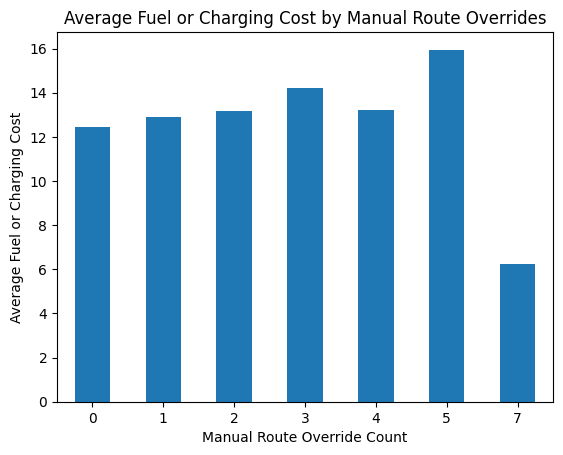

In [20]:
override_cost.plot(kind="bar")
plt.title("Average Fuel or Charging Cost by Manual Route Overrides")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Average Fuel or Charging Cost")
plt.xticks(rotation=0)
plt.show()

In [21]:
complaints_by_service = main_df.groupby("service_type")["has_complaint"].mean().sort_values(ascending=False) * 100
complaints_by_service

,has_complaint
service_type,
Retail,23.214286
Passenger,22.519084
Business,22.222222
Parcel,21.304348
Medical,19.444444


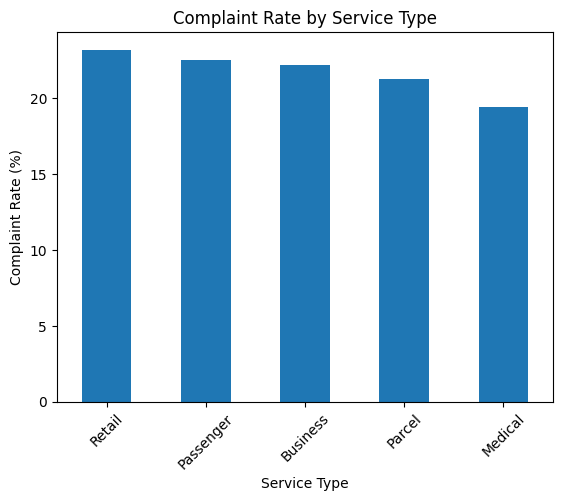

In [22]:
complaints_by_service.plot(kind="bar")
plt.title("Complaint Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Complaint Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [23]:
app_events["success_flag"] = pd.to_numeric(app_events["success_flag"], errors="coerce")

app_failure_by_type = app_events.groupby("event_type")["success_flag"].apply(
    lambda x: (1 - x.mean()) * 100
).sort_values(ascending=False)

app_failure_by_type

,success_flag
event_type,
chat_escalated,50.000000
payment_retry,27.536232
chat_opened,0.000000
cancel_attempt,0.000000
delivery_instruction_update,0.000000
eta_refresh,0.000000
search_route,0.000000
track_order,0.000000


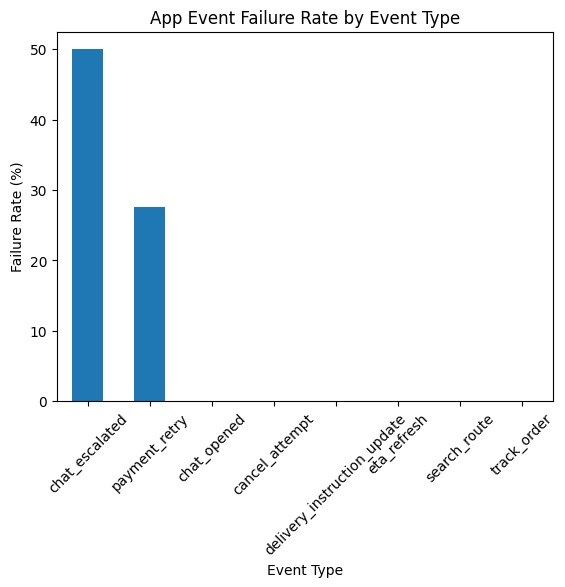

In [24]:
app_failure_by_type.plot(kind="bar")
plt.title("App Event Failure Rate by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.show()